In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error
from torch.utils.hipify.hipify_python import preprocessor

In [3]:
import shap

In [4]:
# 주제 : 제조 공정 품질 이상 분류 모델 개발 실습

# --> 가상 제조 공정 데이터 기반으로, 제품이 정상인지 불량인지를 예측하는 분류 모델을 개발.

# 데이터는 다음과 같은 문제가 포함되어 있다

# 결측치 존재
# 이상치 존재 가능
# 수치형 + 범주형 혼합 데이터
# 원시 센서값만으로는 성능이 제한적일 수 있음
# feature engineering 및 모델 비교가 필요함.

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

np.random.seed(42)

# ============================================================
# 1. 가상 제조 데이터 생성
# ============================================================

n_samples = 1500

temperature = np.random.normal(75, 10, n_samples)        # 공정 온도
pressure = np.random.normal(30, 5, n_samples)            # 압력
vibration = np.random.normal(4.5, 1.2, n_samples)        # 진동
humidity = np.random.normal(45, 12, n_samples)           # 습도
torque = np.random.normal(220, 35, n_samples)            # 토크
speed = np.random.normal(1500, 250, n_samples)           # 회전속도
operator_experience = np.random.normal(5, 2, n_samples)  # 작업자 숙련도(년수)

machine_type = np.random.choice(['A', 'B', 'C'], n_samples, p=[0.4, 0.35, 0.25])
shift = np.random.choice(['day', 'night'], n_samples, p=[0.6, 0.4])
material_grade = np.random.choice(['low', 'medium', 'high'], n_samples, p=[0.2, 0.5, 0.3])

# 품질 불량 확률 생성용 내부 로직
risk_score = (
    0.04 * (temperature - 75) +
    0.07 * (pressure - 30) +
    0.35 * (vibration - 4.5) +
    0.015 * (humidity - 45) +
    0.01 * (torque - 220) -
    0.003 * (speed - 1500) -
    0.15 * (operator_experience - 5)
)

# 범주형 영향
risk_score += np.where(machine_type == 'C', 0.45, 0.0)
risk_score += np.where(shift == 'night', 0.35, 0.0)
risk_score += np.where(material_grade == 'low', 0.50, 0.0)
risk_score += np.where(material_grade == 'high', -0.20, 0.0)

# 비선형/상호작용 영향
risk_score += 0.0008 * (temperature * vibration)
risk_score += 0.0005 * (pressure * humidity)
risk_score += np.where((temperature > 90) & (vibration > 6), 1.0, 0.0)

# sigmoid로 확률화
prob = 1 / (1 + np.exp(-risk_score))
target = np.random.binomial(1, prob)

df = pd.DataFrame({
    'temperature': temperature,
    'pressure': pressure,
    'vibration': vibration,
    'humidity': humidity,
    'torque': torque,
    'speed': speed,
    'operator_experience': operator_experience,
    'machine_type': machine_type,
    'shift': shift,
    'material_grade': material_grade,
    'defect': target
})

# ============================================================
# 2. 결측치 삽입 (실습 난이도 향상)
# ============================================================

for col in ['temperature', 'pressure', 'vibration', 'humidity', 'torque']:
    idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

for col in ['machine_type', 'material_grade']:
    idx = np.random.choice(df.index, size=int(0.03 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

In [7]:
df

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade,defect
0,79.967142,33.891805,2.210631,NaN,181.007152,1931.423448,6.530804,NaN,day,medium,1
1,73.617357,27.244071,3.467538,28.769896,197.917421,1530.461116,7.146825,B,day,medium,0
2,81.476885,25.909006,4.003673,25.996939,187.027894,1688.354368,5.997380,B,day,medium,0
3,90.230299,29.983128,6.765225,49.955987,200.820146,1524.956579,1.115005,C,night,low,1
4,NaN,29.149077,5.167864,42.431188,212.504739,1333.166655,4.689155,C,night,medium,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,95.060929,30.387403,6.512853,47.057632,NaN,1525.407513,4.478783,B,night,high,1
1496,95.615036,31.288763,3.533794,58.831777,201.935918,1791.804433,2.025251,C,day,high,1
1497,87.083662,23.791197,NaN,30.391154,294.359468,1897.111794,5.174410,C,night,high,1
1498,85.240625,31.670882,NaN,50.615405,122.916477,1328.753205,7.494607,C,day,medium,0


- defect 가 y.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          1425 non-null   float64
 1   pressure             1425 non-null   float64
 2   vibration            1425 non-null   float64
 3   humidity             1425 non-null   float64
 4   torque               1425 non-null   float64
 5   speed                1500 non-null   float64
 6   operator_experience  1500 non-null   float64
 7   machine_type         1455 non-null   object 
 8   shift                1500 non-null   object 
 9   material_grade       1455 non-null   object 
 10  defect               1500 non-null   int32  
dtypes: float64(7), int32(1), object(3)
memory usage: 123.2+ KB


In [9]:
df.describe()

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,defect
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1500.000000,1500.000000,1500.000000
mean,75.445962,30.080561,4.455149,44.682296,219.328245,1505.733997,4.981219,0.712667
std,9.901780,4.920217,1.228948,11.994191,36.193789,254.727523,1.920574,0.452669
min,42.587327,14.902439,0.890841,6.879554,107.264428,540.836113,-2.844801,0.000000
25%,68.744373,26.822211,3.615876,36.849232,194.203972,1335.656973,3.680445,0.000000
50%,75.455718,30.001035,4.488854,44.795927,218.553198,1503.048068,5.009714,1.000000
75%,81.818915,33.341702,5.275787,52.827674,244.753098,1674.060157,6.273265,1.000000
max,113.527315,49.631189,8.391712,82.354922,343.516932,2344.345730,10.828218,1.000000


In [10]:
df.isnull().count()

temperature            1500
pressure               1500
vibration              1500
humidity               1500
torque                 1500
speed                  1500
operator_experience    1500
machine_type           1500
shift                  1500
material_grade         1500
defect                 1500
dtype: int64

In [11]:
df.columns

Index(['temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed',
       'operator_experience', 'machine_type', 'shift', 'material_grade',
       'defect'],
      dtype='object')

<Axes: >

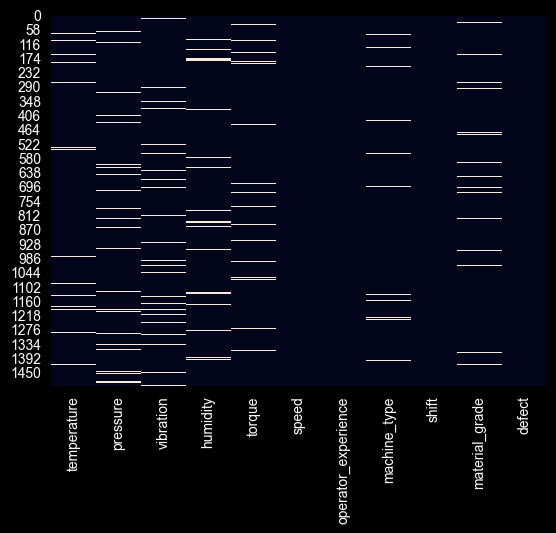

In [12]:
sns.heatmap(df.isnull(),cbar=False)

In [13]:
y = df['defect']
X = df.drop('defect',axis=1)

In [14]:
# 1. 데이터 분할 (항상 결측치 처리 전에 Train/Test를 나눠야 Data Leakage를 막습니다)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True) # y도 꼭 같이 해줘야 데이터가 안 어긋납니다!
y_test = y_test.reset_index(drop=True)

# 결측치와 범주형 변수를 적절히 처리하기

In [15]:
import miceforest as mf

In [16]:
num_cols = ['temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed', 'operator_experience']
cat_cols = ['machine_type', 'shift', 'material_grade']

In [17]:
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [18]:
# 학습 시작
kernel = mf.ImputationKernel(
    X_train,
    num_datasets=1,       # 하나의 완성된 데이터셋만 반환
    random_state=42
)

kernel.mice(iterations=3) # (보통 iterations=2~3 정도면 충분히 수렴)

# 빈칸이 채워진 Train 데이터 꺼내기
X_train_imputed = kernel.complete_data()

# Train에서 학습한 패턴을 바탕으로 Test 데이터 빈칸 채우기
X_test_imputed = kernel.impute_new_data(X_test).complete_data()

In [19]:
X_test_imputed

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade
0,82.326401,34.242154,5.981702,58.499191,243.629797,1475.999835,4.772686,C,day,low
1,76.503938,31.400806,3.823263,39.309862,264.378617,1618.814651,5.733212,C,day,medium
2,74.008241,33.448539,1.631635,38.507918,253.610681,1172.112716,8.662354,C,day,high
3,98.193295,28.719101,3.781875,50.424814,183.085344,1414.166206,5.236700,B,day,medium
4,67.221833,40.447694,4.587449,66.617161,247.192785,1780.297036,7.969284,A,day,medium
...,...,...,...,...,...,...,...,...,...,...
295,84.960477,22.414132,4.349791,34.275048,192.973266,1394.041615,4.156835,A,night,high
296,86.965715,32.043037,3.784045,38.199539,256.330438,1617.847816,3.110183,B,day,high
297,70.393612,25.008073,5.890889,43.794291,220.069190,1502.965670,7.556562,C,night,low
298,77.449666,27.256375,3.268357,53.227077,214.971916,1664.535759,7.793520,B,night,high


<Axes: >

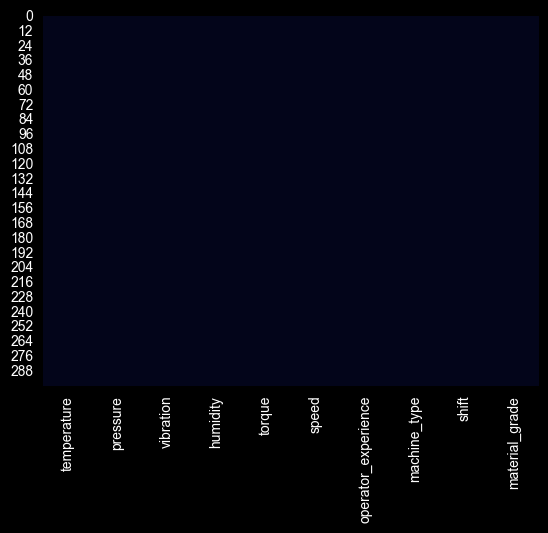

In [20]:
sns.heatmap(X_test_imputed.isnull(),cbar=False)

# 최소 3개 이상의 새로운 feature를 engineering

In [21]:
def create_domain_features(data):
    # SettingWithCopyWarning 방지를 위해 복사본 사용
    df_engineered = data.copy()

    df_engineered['temp_pressure'] = df_engineered['temperature'] / df_engineered['pressure']
    df_engineered['vibration_torque_interaction'] = df_engineered['vibration'] * df_engineered['torque']
    df_engineered['energy'] = df_engineered['torque'] * df_engineered['speed']
    df_engineered['temp_humidity_gap'] = df_engineered['temperature'] - df_engineered['humidity']
    df_engineered['stress_index'] = df_engineered['pressure'] * df_engineered['vibration'] / (df_engineered['operator_experience'] + 1)

    return df_engineered

In [22]:
X_train_imputed = create_domain_features(X_train_imputed)
X_test_imputed = create_domain_features(X_test_imputed)

In [23]:
new_features = ['temp_pressure', 'vibration_torque_interaction', 'energy', 'temp_humidity_gap', 'stress_index']
num_cols_updated = num_cols + new_features

In [24]:
# 스케일링 적용
scaler = StandardScaler()
X_train_imputed[num_cols_updated] = scaler.fit_transform(X_train_imputed[num_cols_updated])
X_test_imputed[num_cols_updated] = scaler.transform(X_test_imputed[num_cols_updated])

In [25]:
X_train_encoded = pd.get_dummies(X_train_imputed,cat_cols)
X_test_encoded = pd.get_dummies(X_test_imputed,cat_cols)
X_test_encoded

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,temp_pressure,vibration_torque_interaction,energy,temp_humidity_gap,stress_index,machine_type_A,machine_type_B,machine_type_C,shift_day,shift_night,material_grade_high,material_grade_low,material_grade_medium
0,0.711262,0.864149,1.227517,1.125893,0.681694,-0.126675,-0.128783,-0.308868,1.472599,0.371667,-0.438235,0.435905,False,False,True,True,False,False,True,False
1,0.109197,0.271197,-0.543069,-0.467338,1.248006,0.434819,0.370033,-0.250055,0.086499,1.232734,0.438411,-0.413562,False,False,True,True,False,False,False,True
2,-0.148868,0.698532,-2.340881,-0.533920,0.954109,-1.321444,1.891178,-0.659694,-1.766641,-0.413279,0.327329,-0.999786,False,False,True,True,False,True,False,False
3,2.351959,-0.288439,-0.577020,0.455502,-0.970788,-0.369781,0.112187,1.548961,-0.901808,-0.896145,1.131918,-0.433536,False,True,False,True,False,False,False,True
4,-0.850608,2.159163,0.083799,1.799903,0.778941,1.069707,1.531256,-1.667746,0.468915,1.385054,-1.961251,-0.276054,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.983635,-1.604203,-0.111154,-0.885362,-0.700910,-0.448904,-0.448603,2.228849,-0.445538,-0.768970,1.323222,-0.361768,True,False,False,False,True,True,False,False
296,1.190984,0.405222,-0.575240,-0.559524,1.028341,0.431018,-0.992145,0.258241,-0.040221,1.065559,1.197350,0.148056,False,True,False,True,False,True,False,False
297,-0.522634,-1.062882,1.153022,-0.095009,0.038638,-0.020655,1.316924,0.442782,0.973087,0.008502,-0.256430,-0.443055,False,False,True,False,True,False,True,False
298,0.206989,-0.593691,-0.998263,0.688166,-0.100486,0.614577,1.439980,0.491640,-0.870149,0.349391,-0.412305,-0.784084,False,True,False,False,True,True,False,False


# 최소 3개의 분류 모델을 학습하고 비교하기

In [26]:
X_train_encoded.head()

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,temp_pressure,vibration_torque_interaction,energy,temp_humidity_gap,stress_index,machine_type_A,machine_type_B,machine_type_C,shift_day,shift_night,material_grade_high,material_grade_low,material_grade_medium
0,-1.796898,0.343704,0.002921,0.184059,1.170740,0.171627,-0.091668,-1.361762,0.593283,0.954561,-1.285066,-0.098088,True,False,False,False,True,False,False,True
1,0.157246,-3.018149,-0.191318,0.768522,0.817505,-0.337937,-0.018505,4.299656,0.230218,0.295937,-0.507328,-0.736928,False,True,False,True,False,True,False,False
2,-0.625564,-0.084428,-0.911202,-0.052087,-1.339791,-0.700581,0.868817,-0.432147,-1.274952,-1.316540,-0.355618,-0.644790,True,False,False,False,True,False,False,True
3,-0.595387,-0.430172,-1.398688,0.039001,-0.912409,1.229838,0.701407,-0.160324,-1.452614,0.090875,-0.408430,-0.762662,True,False,False,True,False,False,False,True
4,0.350822,0.300298,0.155311,0.590200,-1.777966,-1.970692,-1.836862,-0.134148,-0.823574,-2.209866,-0.243695,1.585251,True,False,False,True,False,False,False,True


In [27]:
from sklearn.svm import SVC # SVM 분류 모델
svm_clf = SVC(kernel='rbf', C= 1.0, gamma= 'scale')
svm_clf.fit(X_train_encoded, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
y_pred = svm_clf.predict(X_test_encoded)

In [29]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))  # matrix 행렬 출력

print("\nClassification Report")
print(classification_report(y_test, y_pred))  # precision, recall, acc등 출력

Confusion Matrix
[[ 35  51]
 [ 19 195]]

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.41      0.50        86
           1       0.79      0.91      0.85       214

    accuracy                           0.77       300
   macro avg       0.72      0.66      0.67       300
weighted avg       0.75      0.77      0.75       300



In [30]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train_encoded, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
y_test

0      1
1      0
2      1
3      1
4      1
      ..
295    1
296    1
297    1
298    1
299    1
Name: defect, Length: 300, dtype: int32

In [32]:
y_pred = model.predict(X_test_encoded)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))  # matrix 행렬 출력

print("\nClassification Report")
print(classification_report(y_test, y_pred))  # precision, recall, acc등 출력

Confusion Matrix


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [182]:
from xgboost import XGBClassifier

model = XGBClassifier(enable_categorical=True )
clf = model.fit(X_train_encoded, y_train, )

In [185]:
## 예측
print(clf.predict(X_test_encoded)[:3])
print()
## 성능 평가
print('정확도 : ', clf.score(X_test_encoded,y_test)) ## 테스트 성능 평가 점수(Accuracy)
print()
## 변수 중요도
for i, feature in enumerate(clf.feature_names_in_):
    print(f'{feature} : {clf.feature_importances_[i]}')

[1 1 1]

정확도 :  0.7433333333333333

temperature : 0.05283855274319649
pressure : 0.0526743084192276
vibration : 0.04198501631617546
humidity : 0.058247923851013184
torque : 0.06881652772426605
speed : 0.061335574835538864
operator_experience : 0.0384795218706131
temp_pressure : 0.0490071102976799
vibration_torque_interaction : 0.04978981614112854
energy : 0.03617796674370766
temp_humidity_gap : 0.038766976445913315
stress_index : 0.07168295979499817
machine_type_A : 0.029108954593539238
machine_type_B : 0.0435284860432148
machine_type_C : 0.09333164989948273
shift_day : 0.036922890692949295
shift_night : 0.0
material_grade_high : 0.0660591721534729
material_grade_low : 0.07543570548295975
material_grade_medium : 0.035810958594083786


In [ ]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))  # matrix 행렬 출력

print("\nClassification Report")
print(classification_report(y_test, y_pred))  # precision, recall, acc등 출력

In [177]:
explainer = shap.TreeExplainer(model)

# shap 값을 계산 (테스트 데이터 기준)
shap_values = explainer.shap_values(X_test_encoded) # 각 feature 가 예측에 얼마나 기여했는지 score 계산

ValueError: could not convert string to float: '[7.125E-1]'

In [153]:
X_test_encoded.columns

Index(['temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed',
       'operator_experience', 'temp_pressure', 'vibration_torque_interaction',
       'energy', 'temp_humidity_gap', 'stress_index', 'machine_type_A',
       'machine_type_B', 'machine_type_C', 'shift_day', 'shift_night',
       'material_grade_high', 'material_grade_low', 'material_grade_medium'],
      dtype='object')

In [155]:
X_train_encoded.columns

Index(['temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed',
       'operator_experience', 'temp_pressure', 'vibration_torque_interaction',
       'energy', 'temp_humidity_gap', 'stress_index', 'machine_type_A',
       'machine_type_B', 'machine_type_C', 'shift_day', 'shift_night',
       'material_grade_high', 'material_grade_low', 'material_grade_medium'],
      dtype='object')

In [160]:
# 평균 절댓값 기준 중요도
importance = np.abs(shap_values).mean(axis=0)

# 중요도 높은 순 정렬
top_idx = np.argsort(importance)[::-1]

# top feature 이름
top_features = X_train_encoded.columns[top_idx]

print(top_features[:5])

Index(['speed', 'stress_index', 'temperature', 'pressure',
       'vibration_torque_interaction'],
      dtype='object')


C:\Users\human\AppData\Local\Temp\ipykernel_5244\1982563270.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_encoded) # 점 위치 : 영향 방향 (+/-), 색 : feature 값 크기


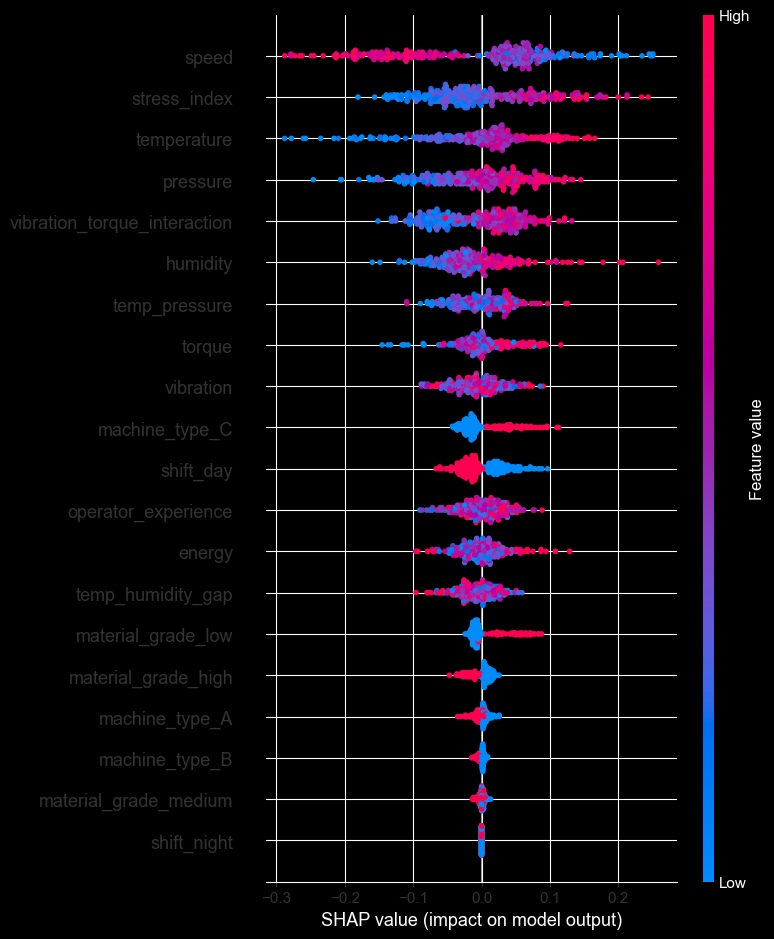

C:\Users\human\AppData\Local\Temp\ipykernel_5244\1982563270.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_encoded, plot_type="bar" )


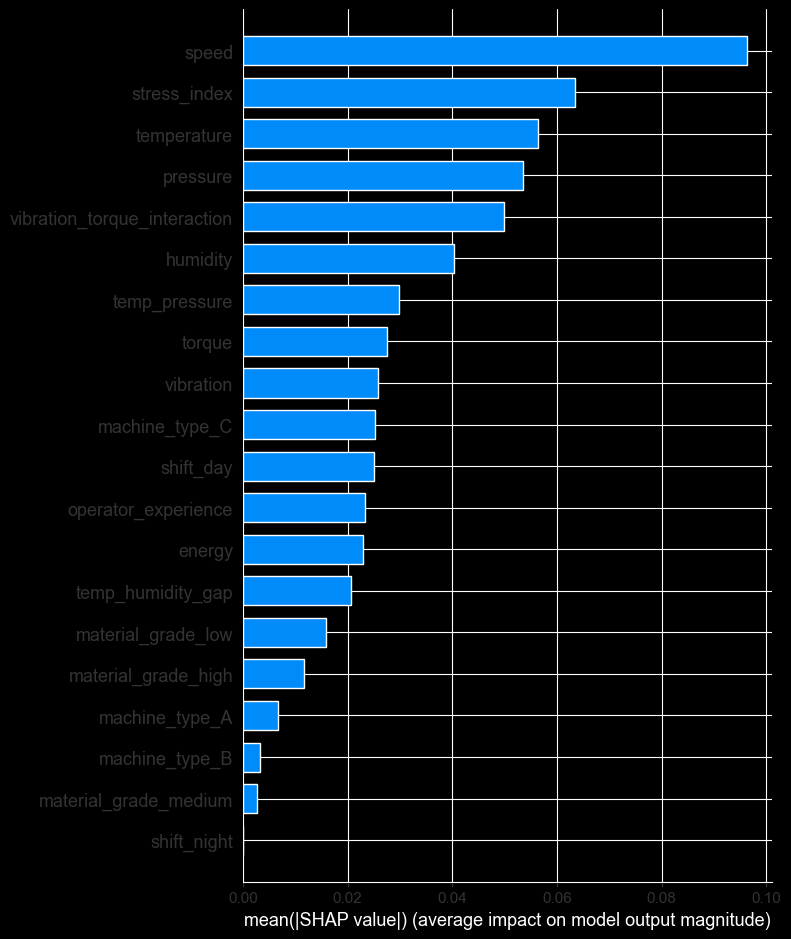

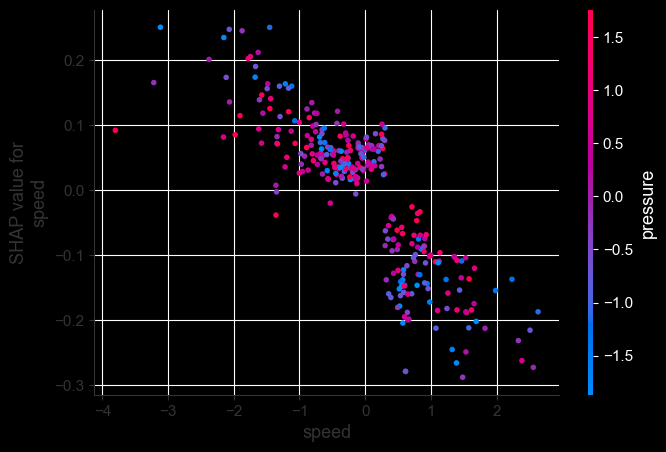

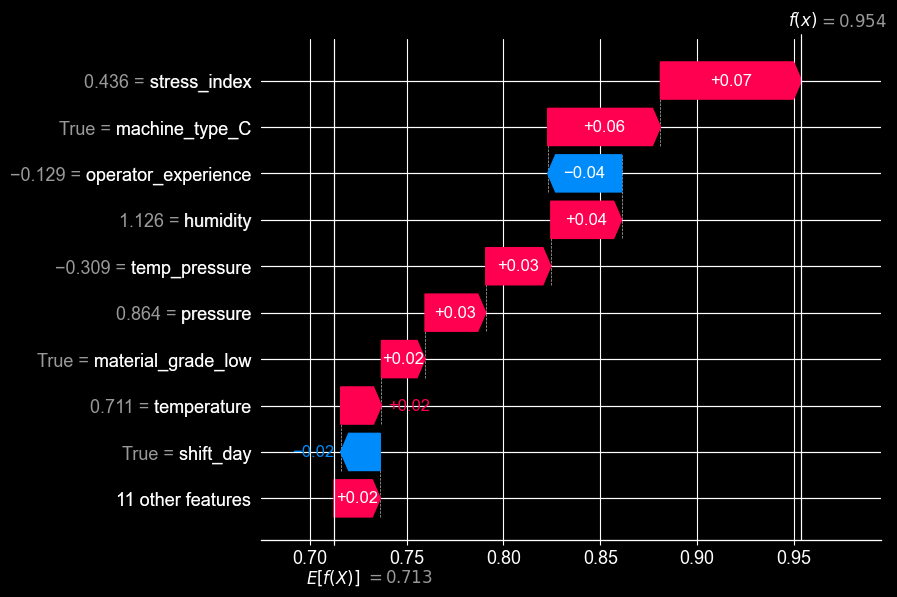


Shap 값 샘플
   temperature  pressure  vibration  humidity    torque     speed  \
0     0.021042  0.031345  -0.007490  0.036583  0.000473  0.010130   
1     0.038324  0.061003  -0.030373 -0.031371  0.070366 -0.075125   
2     0.036807 -0.013851   0.007765 -0.044523  0.085930  0.093141   
3     0.113449 -0.031536  -0.008753  0.101500 -0.028913  0.044703   
4    -0.073022  0.089883   0.017298  0.206929  0.011885 -0.110092   

   operator_experience  temp_pressure  vibration_torque_interaction    energy  \
0            -0.038209       0.033597                     -0.002886  0.017153   
1            -0.017614       0.015518                      0.038821  0.056576   
2             0.024789      -0.047573                     -0.043978  0.032261   
3             0.030281       0.058097                     -0.102666 -0.017804   
4             0.050204      -0.057380                      0.050829  0.075304   

   temp_humidity_gap  stress_index  machine_type_A  machine_type_B  \
0          -0.008

In [162]:
# 영항도 시각화
shap.summary_plot(shap_values, X_test_encoded) # 점 위치 : 영향 방향 (+/-), 색 : feature 값 크기

# shap bar plot (방향성)
shap.summary_plot(shap_values, X_test_encoded, plot_type="bar" )

# shap dependence plot
shap.dependence_plot("speed", shap_values, X_test_encoded)

# shap waterfall plot
sample_index = 0

# 개별 샘플 shap 값
shap.initjs()
shap.waterfall_plot(
    shap.Explanation(
        values = shap_values[sample_index],
        base_values= explainer.expected_value,
        data = X_test_encoded.iloc[sample_index],
        feature_names=X_test_encoded.columns
    )
)


# 그래프 볼 때 색깔 강조해줘서 예측 증가하면 빨강, 감소하면 파랑
# Force plot (interactive)
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_encoded.iloc[0]
)

# shap 값 직접 확인
shap_df = pd.DataFrame(shap_values, columns=X_train_encoded.columns)

print("\nShap 값 샘플")
print(shap_df.head())

In [144]:
## 예측결과 시각화
# 차원을 2개로 축소해서 분류 경계 시각화

from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2차원으로 축소

X_test_pca = pca.fit_transform(X_test_scaled)

# 가장 성능이 좋은 모델을 선정하기

# 테스트 데이터 기준으로 다양한 평가 지표를 제시

# 신규 공정 데이터 5건에 대해 정상/불량을 예측

# 모델 평가 결과와 신규 예측 결과를 시각화

# 어떤 feature 가 예측에 중요한지 해석.